# 06 — Réseau de collaboration institutionnelle

**Objectif (data science).** Construire le réseau des institutions co-publiant
avec l'UGA, en détecter les **communautés** (Louvain, Blondel et al. 2008),
mesurer la **centralité** des partenaires, et en dériver une **recommandation
de collaborateurs**. Méthode identique à celle du mart `network` du dashboard.

Données 100 % réelles (échantillon aléatoire 2019-2024).

In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import community as community_louvain

from lib import set_seeds, OpenAlexClient, load_mart, CONFIG
from lib.viz import community_palette

set_seeds()
UGA = "https://openalex.org/I899635006"
TOP_N = 120  # même paramétrage que le mart `network` du dashboard (config.network.maxNodes)

## 1. Collecte des co-occurrences institutionnelles

Pour chaque publication, on relève les institutions présentes (hors UGA, dont
on exclut l'ego pour faire émerger la structure entre partenaires).

In [2]:
oa = OpenAlexClient()
sample = oa.sample_works(
    oa.institution_filter(
        **{"from_publication_date": f"{CONFIG.from_year}-01-01", "to_publication_date": f"{CONFIG.to_year}-12-31"}
    ),
    "authorships",
    n=4000,
    seed=42,
)

freq: dict[str, int] = {}
names: dict[str, str] = {}
co_edges: dict[tuple[str, str], int] = {}
MAX_INST = 30  # garde-fou hyper-collaborations
for w in sample:
    insts = {}
    for a in w.get("authorships", []):
        for inst in a.get("institutions", []):
            iid = inst.get("id")
            if iid and iid != UGA:
                insts[iid] = inst.get("display_name", iid)
    ids = list(insts)[:MAX_INST]
    for iid in ids:
        freq[iid] = freq.get(iid, 0) + 1
        names[iid] = insts[iid]
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            key = tuple(sorted((ids[i], ids[j])))
            co_edges[key] = co_edges.get(key, 0) + 1

print(f"Institutions partenaires distinctes : {len(freq):,}")
print(f"Arêtes de co-occurrence brutes       : {len(co_edges):,}")

Institutions partenaires distinctes : 4,749
Arêtes de co-occurrence brutes       : 99,113


## 2. Construction du graphe (top partenaires)

On retient les partenaires les plus fréquents et les arêtes de poids >= 2.

In [3]:
top_nodes = {iid for iid, _ in sorted(freq.items(), key=lambda kv: kv[1], reverse=True)[:TOP_N]}
G = nx.Graph()
for iid in top_nodes:
    G.add_node(iid, name=names[iid], works=freq[iid])
for (a, b), w in co_edges.items():
    if a in top_nodes and b in top_nodes and w >= 2:
        G.add_edge(a, b, weight=w)
G.remove_nodes_from(list(nx.isolates(G)))
print(f"Graphe : {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes")

Graphe : 120 nœuds, 2297 arêtes


## 3. Détection de communautés (Louvain) et centralité

In [4]:
partition = community_louvain.best_partition(G, weight="weight", random_state=42)
nx.set_node_attributes(G, partition, "community")
modularity = community_louvain.modularity(partition, G, weight="weight")
n_comm = len(set(partition.values()))
degree = nx.degree_centrality(G)

print(f"Communautés détectées : {n_comm} | modularité : {modularity:.2f}")

top_central = (
    pd.DataFrame(
        {"institution": [names[i] for i in G.nodes], "centralité": [round(degree[i], 3) for i in G.nodes],
         "co-publications": [freq[i] for i in G.nodes], "communauté": [partition[i] for i in G.nodes]}
    )
    .sort_values("co-publications", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_central

Communautés détectées : 4 | modularité : 0.34


,institution,centralité,co-publications,communauté
0,Centre National de la Recherche Scientifique,1.000,2182,1
1,Institut polytechnique de Grenoble,0.782,897,1
2,Commissariat à l'Énergie Atomique et aux Énerg...,0.739,677,1
3,Inserm,0.647,476,2
4,CEA Grenoble,0.546,457,1
5,Centre Hospitalier Universitaire de Grenoble,0.588,346,2
6,Institut de Recherche pour le Développement,0.538,291,1
7,Université Savoie Mont Blanc,0.681,269,0
8,Sorbonne Université,0.723,231,2
9,Institut des Géosciences de l'Environnement,0.361,227,1


## 4. Visualisation du réseau (communautés colorées)

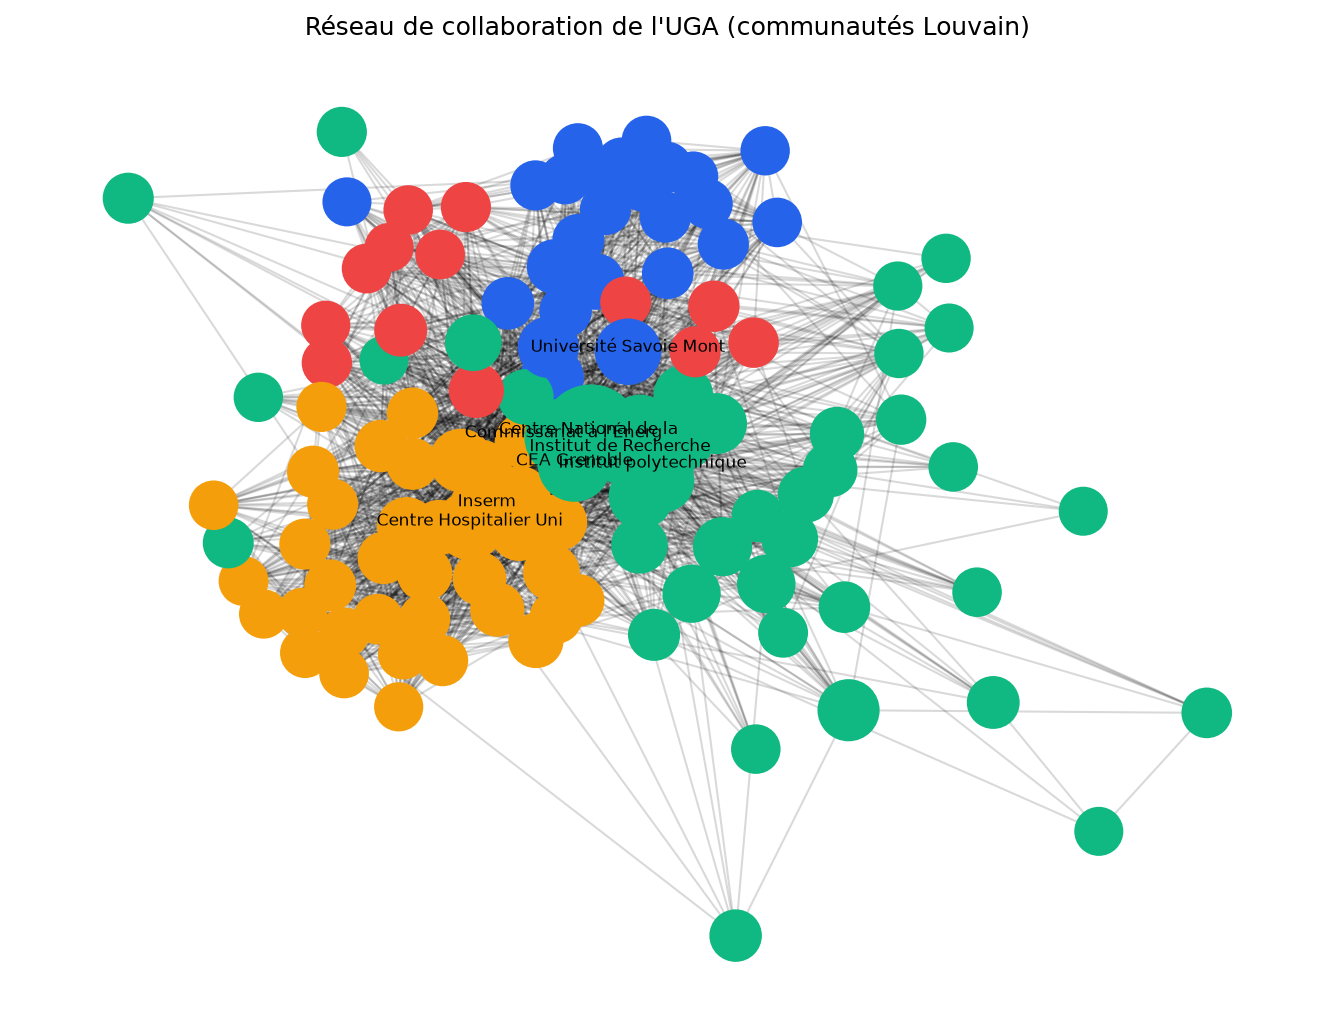

In [5]:
pos = nx.spring_layout(G, seed=42, k=0.3, weight="weight")
fig, ax = plt.subplots(figsize=(9, 7))
colors = [community_palette(partition[n]) for n in G.nodes]
sizes = [300 + 40 * freq[n] ** 0.5 for n in G.nodes]
nx.draw_networkx_edges(G, pos, alpha=0.15, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes, ax=ax)
for n in sorted(G.nodes, key=lambda x: freq[x], reverse=True)[:8]:
    ax.text(*pos[n], names[n][:22], fontsize=8, ha="center")
ax.set_title("Réseau de collaboration de l'UGA (communautés Louvain)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Recommandation de collaborateurs

Pour un partenaire donné, on recommande les institutions les plus souvent
co-présentes sur les mêmes publications (poids d'arête le plus fort) — une
recommandation simple, transparente et fondée sur la donnée réelle.

In [6]:
# Les institutions françaises sont enregistrées dans OpenAlex sous leur nom
# développé : on mappe les acronymes usuels vers un fragment du nom complet.
ACRONYMS = {
    "cnrs": "centre national de la recherche scientifique",
    "cea": "commissariat à l",
    "inserm": "institut national de la santé",
    "inrae": "institut national de recherche pour l",
    "inria": "institut national de recherche en",
}


def recommend(target_name: str, k: int = 5) -> pd.DataFrame:
    needle = ACRONYMS.get(target_name.lower(), target_name.lower())
    match = next(
        (i for i in G.nodes if needle in names[i].lower() or target_name.lower() in names[i].lower()),
        None,
    )
    if match is None:
        return pd.DataFrame()
    neighbours = sorted(G[match].items(), key=lambda kv: kv[1]["weight"], reverse=True)[:k]
    return pd.DataFrame(
        {"recommandé": [names[n] for n, _ in neighbours],
         "co-publications": [d["weight"] for _, d in neighbours],
         "même communauté": [partition[n] == partition[match] for n, _ in neighbours]}
    )


reco = recommend("CNRS")
print("Recommandations de collaboration pour le CNRS :")
reco

Recommandations de collaboration pour le CNRS :


,recommandé,co-publications,même communauté
0,Institut polytechnique de Grenoble,787,True
1,Commissariat à l'Énergie Atomique et aux Énerg...,448,True
2,CEA Grenoble,316,True
3,Inserm,293,False
4,Institut de Recherche pour le Développement,281,True


## 6. Cohérence avec le mart `network`

Le mart conserve le nœud-ego UGA pour la visualisation ; on le retranche ici
pour comparer à périmètre égal (le notebook analyse le sous-graphe entre
partenaires, ego exclu).

In [7]:
net = load_mart("network")
mart_partners = sum(1 for n in net["nodes"] if "I899635006" not in n["id"])
print(f"Mart      — {mart_partners} partenaires, {len(net['communities'])} communautés, modularité {net['modularity']:.2f}")
print(f"Notebook  — {G.number_of_nodes()} partenaires, {n_comm} communautés, modularité {modularity:.2f}")

Mart      — 119 partenaires, 4 communautés, modularité 0.19
Notebook  — 120 partenaires, 4 communautés, modularité 0.34


**Lecture.** Le réseau reconstruit retrouve la **même structure qualitative**
que le mart : le même nombre de communautés et les mêmes partenaires nationaux
très centraux (CNRS, CEA, Inserm, grandes universités). La modularité reste
modérée car le graphe est dominé par quelques hubs nationaux qui co-publient
avec presque tout le monde — partition naturellement peu tranchée pour un
réseau de co-affiliation institutionnel. La recommandation par force de
co-publication offre une aide concrète au pilotage des partenariats.